24BAD061 - KRITHIKA K
# Exploring Word Representations: From Traditional Word Embeddings to Transformers

This notebook explores different techniques for representing text and words numerically.
The study progresses from traditional text representations such as TF-IDF to predictive
word embeddings such as Word2Vec and FastText, neural embeddings using TensorFlow/Keras,
and contextual embeddings using BERT.

The notebook also calculates semantic similarity between words and visualizes high-dimensional
embeddings using PCA.

### Techniques Covered

1. TF-IDF
2. Word2Vec – Skip-gram
3. FastText
4. TensorFlow/Keras Embedding Layer
5. BERT contextual embeddings
6. Cosine similarity
7. PCA embedding visualization

### Expected Outcome

The experiments demonstrate the differences between traditional, static, neural and
contextual word representations and show how embeddings capture semantic relationships.

In [ ]:
!pip install -q gensim transformers sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 35.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

from gensim.models import Word2Vec, FastText

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

import torch
from transformers import AutoTokenizer, AutoModel

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)
print("PyTorch version:", torch.__version__)

TensorFlow version: 2.21.0
PyTorch version: 2.11.0+cpu


## 1. Dataset

A small text corpus related to artificial intelligence, machine learning,
deep learning, programming, education and natural language processing is used.

The same corpus is used wherever possible so that the different representation
techniques can be compared under similar conditions.

In [ ]:
documents = [
    "Machine learning is a branch of artificial intelligence.",
    "Deep learning is a part of machine learning.",
    "Artificial intelligence helps computers learn from data.",
    "Students learn machine learning and deep learning.",
    "Data science uses machine learning for prediction.",
    "Neural networks are widely used in deep learning.",
    "Python is widely used for machine learning and data science.",
    "Python programming helps students build machine learning applications.",
    "Transformers are powerful models for natural language processing.",
    "BERT is a transformer model for language understanding.",
    "Word embeddings represent words as numerical vectors.",
    "Word2Vec learns meaningful representations of words.",
    "FastText uses subword information to represent words.",
    "Natural language processing allows computers to understand human language.",
    "Deep neural networks are useful for image and language tasks.",
    "Students use Python for artificial intelligence projects.",
    "Data science combines statistics programming and machine learning.",
    "Artificial intelligence is used in healthcare education and finance.",
    "Machine learning models can make predictions from historical data.",
    "Natural language processing is an important field of artificial intelligence."
]

print("Number of documents:", len(documents))

for i, doc in enumerate(documents[:5], 1):
    print(f"{i}. {doc}")

Number of documents: 20
1. Machine learning is a branch of artificial intelligence.
2. Deep learning is a part of machine learning.
3. Artificial intelligence helps computers learn from data.
4. Students learn machine learning and deep learning.
5. Data science uses machine learning for prediction.


In [ ]:
import re

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

clean_documents = [preprocess_text(doc) for doc in documents]

print("Original:")
print(documents[0])

print("\nPreprocessed:")
print(clean_documents[0])

Original:
Machine learning is a branch of artificial intelligence.

Preprocessed:
machine learning is a branch of artificial intelligence


## 2. Traditional Text Representation

### One-Hot Encoding

One-Hot Encoding represents each word using a binary vector.
Only one position in the vector is set to 1 and all other positions are 0.

For example, if the vocabulary is:

[python, machine, learning, data]

then:

python → [1,0,0,0]

machine → [0,1,0,0]

learning → [0,0,1,0]

data → [0,0,0,1]

### Limitation

One-Hot Encoding does not capture semantic relationships between words.
For example, "machine" and "computer" are represented as completely independent vectors.

In [ ]:
sample_words = ["python", "machine", "learning", "data"]

one_hot_vectors = np.eye(len(sample_words))

one_hot_df = pd.DataFrame(
    one_hot_vectors,
    index=sample_words,
    columns=sample_words
)

one_hot_df

,python,machine,learning,data
python,1.0,0.0,0.0,0.0
machine,0.0,1.0,0.0,0.0
learning,0.0,0.0,1.0,0.0
data,0.0,0.0,0.0,1.0


### Bag of Words

Bag of Words represents each document according to the frequency of words appearing
in that document.

It ignores the order of words and mainly captures word frequency.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(clean_documents)

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=bow_vectorizer.get_feature_names_out()
)

print("BoW matrix shape:", bow_df.shape)

bow_df.head()

BoW matrix shape: (20, 75)


,allows,an,and,applications,are,artificial,as,bert,branch,build,...,understanding,use,used,useful,uses,vectors,widely,word,words,wordvec
0,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


## 3. TF-IDF Representation

TF-IDF stands for Term Frequency–Inverse Document Frequency.

It assigns a higher weight to words that are important in a document but occur
less frequently across the entire collection of documents.

TF-IDF is calculated using:

TF-IDF = TF × IDF


In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

tfidf_matrix = tfidf_vectorizer.fit_transform(clean_documents)

tfidf_features = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_features
)

print("TF-IDF matrix shape:", tfidf_df.shape)

tfidf_df.head()

TF-IDF matrix shape: (20, 63)


,allows,applications,artificial,bert,branch,build,combines,computers,data,deep,...,understanding,use,used,useful,uses,vectors,widely,word,words,wordvec
0,0.0,0.0,0.427042,0.0,0.6353,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.000000,0.0,0.0000,0.0,0.0,0.000000,0.000000,0.525414,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.350712,0.0,0.0000,0.0,0.0,0.458622,0.350712,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.000000,0.0,0.0000,0.0,0.0,0.000000,0.000000,0.399119,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.000000,0.0,0.0000,0.0,0.0,0.000000,0.363075,0.000000,...,0.0,0.0,0.0,0.0,0.474788,0.0,0.0,0.0,0.0,0.0


In [ ]:
query = ["machine learning"]

query_vector = tfidf_vectorizer.transform(query)

similarities = cosine_similarity(query_vector, tfidf_matrix)[0]

results = pd.DataFrame({
    "Document": documents,
    "Similarity": similarities
})

results = results.sort_values(
    by="Similarity",
    ascending=False
)

results.head(5)

,Document,Similarity
1,Deep learning is a part of machine learning.,0.805707
3,Students learn machine learning and deep learn...,0.612037
0,Machine learning is a branch of artificial int...,0.481315
4,Data science uses machine learning for predict...,0.409218
6,Python is widely used for machine learning and...,0.394621


# 4. Word2Vec

Word2Vec is a predictive word embedding technique that represents words as
dense numerical vectors.

Two major architectures are:

### CBOW
Continuous Bag of Words predicts a target word from surrounding context words.

### Skip-gram
Skip-gram predicts surrounding context words from a target word.

In this experiment, the Skip-gram architecture is implemented.

Word2Vec produces static embeddings, meaning a word generally has one vector
regardless of the context in which it appears.

In [ ]:
tokenized_sentences = [
    sentence.split()
    for sentence in clean_documents
]

print(tokenized_sentences[:3])

[['machine', 'learning', 'is', 'a', 'branch', 'of', 'artificial', 'intelligence'], ['deep', 'learning', 'is', 'a', 'part', 'of', 'machine', 'learning'], ['artificial', 'intelligence', 'helps', 'computers', 'learn', 'from', 'data']]


In [ ]:
word2vec_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=3,
    min_count=1,
    workers=4,
    sg=1,          # 1 = Skip-gram
    epochs=100
)

print("Word2Vec vocabulary size:",
      len(word2vec_model.wv.index_to_key))

Word2Vec vocabulary size: 76


In [ ]:
word = "machine"

embedding = word2vec_model.wv[word]

print("Word:", word)
print("Embedding dimension:", len(embedding))
print("\nFirst 20 values:")
print(embedding[:20])

Word: machine
Embedding dimension: 100

First 20 values:
[-0.00820624  0.00628906 -0.00852981  0.01561044  0.01717322 -0.04600578
  0.01981615  0.06755106 -0.04032351 -0.05634228  0.00171609 -0.04216595
 -0.0002254   0.01047671  0.02970663 -0.01077444  0.03810964 -0.02314712
 -0.01699785 -0.08341511]


In [ ]:
query_words = ["machine", "learning", "python", "data"]

for word in query_words:
    print("\nQuery:", word)
    print(word2vec_model.wv.most_similar(word, topn=5))


Query: machine
[('for', 0.9690161347389221), ('language', 0.9681875109672546), ('learning', 0.9642618894577026), ('words', 0.9626560211181641), ('is', 0.9592498540878296)]

Query: learning
[('language', 0.9705841541290283), ('are', 0.9671573042869568), ('words', 0.9661867618560791), ('to', 0.9661587476730347), ('for', 0.9659508466720581)]

Query: python
[('for', 0.9329145550727844), ('machine', 0.9303967952728271), ('science', 0.9246763586997986), ('as', 0.9200063347816467), ('intelligence', 0.9182248115539551)]

Query: data
[('language', 0.967562198638916), ('predictions', 0.9648417830467224), ('for', 0.9633875489234924), ('are', 0.956672728061676), ('represent', 0.9566476345062256)]


In [ ]:
def show_similar_words(model, words, topn=5):
    for word in words:
        print("\n" + "=" * 40)
        print("Query word:", word)

        if word in model.wv:
            similar = model.wv.most_similar(word, topn=topn)

            for rank, (similar_word, score) in enumerate(similar, 1):
                print(
                    f"{rank}. {similar_word:<15} "
                    f"Similarity: {score:.4f}"
                )
        else:
            print("Word not found in vocabulary.")

show_similar_words(
    word2vec_model,
    ["machine", "learning", "python", "data", "language"]
)


Query word: machine
1. for             Similarity: 0.9690
2. language        Similarity: 0.9682
3. learning        Similarity: 0.9643
4. words           Similarity: 0.9627
5. is              Similarity: 0.9592

Query word: learning
1. language        Similarity: 0.9706
2. are             Similarity: 0.9672
3. words           Similarity: 0.9662
4. to              Similarity: 0.9662
5. for             Similarity: 0.9660

Query word: python
1. for             Similarity: 0.9329
2. machine         Similarity: 0.9304
3. science         Similarity: 0.9247
4. as              Similarity: 0.9200
5. intelligence    Similarity: 0.9182

Query word: data
1. language        Similarity: 0.9676
2. predictions     Similarity: 0.9648
3. for             Similarity: 0.9634
4. are             Similarity: 0.9567
5. represent       Similarity: 0.9566

Query word: language
1. for             Similarity: 0.9770
2. words           Similarity: 0.9766
3. is              Similarity: 0.9752
4. to              Simi

# 5. FastText

FastText is an extension of Word2Vec that represents words using character
n-grams as well as the complete word.

This allows FastText to represent rare words and unseen words more effectively
than standard Word2Vec.

For example, words such as:

learning
learner
learned

share character-level information.

Therefore, FastText can generate useful representations even when a complete
word was not present in the training vocabulary.

In [ ]:
fasttext_model = FastText(
    sentences=tokenized_sentences,
    vector_size=100,
    window=3,
    min_count=1,
    workers=4,
    sg=1,
    epochs=100
)

print(
    "FastText vocabulary size:",
    len(fasttext_model.wv.index_to_key)
)

FastText vocabulary size: 76


In [ ]:
for word in ["machine", "learning", "python", "data"]:
    print("\nQuery:", word)

    similar_words = fasttext_model.wv.most_similar(
        word,
        topn=5
    )

    for rank, (similar_word, score) in enumerate(similar_words, 1):
        print(
            f"{rank}. {similar_word:<15} "
            f"Similarity: {score:.4f}"
        )


Query: machine
1. language        Similarity: 0.9978
2. processing      Similarity: 0.9977
3. representations Similarity: 0.9976
4. predictions     Similarity: 0.9974
5. transformers    Similarity: 0.9974

Query: learning
1. understanding   Similarity: 0.9989
2. learn           Similarity: 0.9987
3. processing      Similarity: 0.9986
4. representations Similarity: 0.9986
5. learns          Similarity: 0.9985

Query: python
1. representations Similarity: 0.9940
2. predictions     Similarity: 0.9940
3. intelligence    Similarity: 0.9939
4. words           Similarity: 0.9938
5. represent       Similarity: 0.9938

Query: data
1. machine         Similarity: 0.9934
2. representations Similarity: 0.9932
3. represent       Similarity: 0.9928
4. predictions     Similarity: 0.9924
5. learning        Similarity: 0.9923


## FastText Out-of-Vocabulary Experiment

A major advantage of FastText is its use of character n-grams.

Standard Word2Vec generally cannot generate a meaningful vector for a completely
unknown word.

FastText can construct an embedding from subword information.

Therefore, FastText is generally more robust for rare and out-of-vocabulary words.

In [ ]:
test_oov_words = [
    "machinelearning",
    "learners",
    "programming",
    "artificialintelligence"
]

for word in test_oov_words:
    vector = fasttext_model.wv[word]

    print(
        f"Word: {word:<25} "
        f"Vector dimension: {len(vector)} "
        f"Norm: {np.linalg.norm(vector):.4f}"
    )

Word: machinelearning           Vector dimension: 100 Norm: 0.1849
Word: learners                  Vector dimension: 100 Norm: 0.1841
Word: programming               Vector dimension: 100 Norm: 0.1732
Word: artificialintelligence    Vector dimension: 100 Norm: 0.1388


In [ ]:
test_word = "machinelearning"

print("Testing:", test_word)

# Word2Vec
try:
    word2vec_vector = word2vec_model.wv[test_word]
    print("Word2Vec: Vector found")
except KeyError:
    print("Word2Vec: Out-of-vocabulary")

# FastText
try:
    fasttext_vector = fasttext_model.wv[test_word]
    print("FastText: Vector generated")
except KeyError:
    print("FastText: Out-of-vocabulary")

Testing: machinelearning
Word2Vec: Out-of-vocabulary
FastText: Vector generated


# 6. Neural Word Embeddings Using TensorFlow and Keras

The Keras Embedding layer maps integer word IDs to dense vectors.

The general process is:

Text
↓
Tokenization
↓
Integer sequences
↓
Embedding Layer
↓
Dense word representations

Unlike One-Hot Encoding, the embedding layer produces compact dense vectors.
The vectors can be learned during neural network training.

In [ ]:
keras_tokenizer = Tokenizer(
    num_words=1000,
    oov_token="<OOV>"
)

keras_tokenizer.fit_on_texts(clean_documents)

sequences = keras_tokenizer.texts_to_sequences(clean_documents)

word_index = keras_tokenizer.word_index

print("Vocabulary size:", len(word_index))

print("\nExample:")
print(clean_documents[0])
print(sequences[0])

Vocabulary size: 77

Example:
machine learning is a branch of artificial intelligence
[3, 2, 4, 13, 35, 11, 7, 8]


In [ ]:
max_length = max(len(sequence) for sequence in sequences)

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post"
)

print("Maximum sequence length:", max_length)
print("\nPadded shape:", padded_sequences.shape)
print("\nFirst padded sequence:")
print(padded_sequences[0])

Maximum sequence length: 10

Padded shape: (20, 10)

First padded sequence:
[ 3  2  4 13 35 11  7  8  0  0]


In [ ]:
vocab_size = len(word_index) + 1
embedding_dimension = 32

keras_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dimension,
        input_length=max_length
    ),
    GlobalAveragePooling1D(),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

keras_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Example binary labels:
# 1 = AI/ML related
# 0 = other/general language-related

labels = np.array([
    1, 1, 1, 1, 1,
    1, 1, 1, 1, 1,
    1, 1, 1, 1, 1,
    1, 1, 1, 1, 1
])

print("Labels shape:", labels.shape)

Labels shape: (20,)


In [ ]:
history = keras_model.fit(
    padded_sequences,
    labels,
    epochs=20,
    verbose=1
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.6500 - loss: 0.6904
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9500 - loss: 0.6848
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 1.0000 - loss: 0.6791
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 1.0000 - loss: 0.6729
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 1.0000 - loss: 0.6659
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 1.0000 - loss: 0.6583
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 1.0000 - loss: 0.6504
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 1.0000 - loss: 0.6423
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 1.0000 - loss: 0.6339
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 1.0000 - loss: 0.6253
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 1.0000 - loss: 0.6166
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 1.0000 - loss: 0.607

In [ ]:
embedding_layer = keras_model.layers[0]

keras_weights = embedding_layer.get_weights()[0]

print("Keras embedding matrix shape:")
print(keras_weights.shape)

Keras embedding matrix shape:
(78, 32)


In [ ]:
index_to_word = {
    index: word
    for word, index in word_index.items()
}

for index in range(1, min(11, len(index_to_word) + 1)):
    word = index_to_word[index]

    print(
        f"{word:<20} "
        f"{keras_weights[index][:5]}"
    )

<OOV>                [-0.01079559 -0.02498006  0.00387977 -0.00744209  0.03737576]
learning             [ 0.06245851  0.04541727 -0.0719495  -0.01058139  0.05566244]
machine              [ 0.08387359  0.01793968 -0.01218339  0.01740539  0.03060779]
is                   [ 0.04824958  0.0452347  -0.04363437  0.06804827  0.0867978 ]
for                  [ 0.0421426   0.03049827 -0.0902444  -0.01659045 -0.00120505]
language             [ 0.04239166  0.0874335  -0.07184609  0.02020832  0.09107886]
artificial           [ 0.00898285  0.04621837 -0.09378543  0.00288284  0.05500954]
intelligence         [ 0.07393737 -0.00345438 -0.04281646  0.03863703  0.05591679]
data                 [ 0.01306839  0.01902373 -0.03355474  0.005325    0.06521402]
and                  [ 0.03887529  0.0723441  -0.05577324 -0.01829574  0.05945453]


# 7. Transformer-Based NLP – BERT

BERT stands for Bidirectional Encoder Representations from Transformers.

BERT generates contextual word representations. This means that the representation
of a word depends on the surrounding words.

For example, consider the word "bank":

1. I deposited money in the bank.
2. We sat beside the river bank.

Although the word "bank" is identical, its meaning changes according to context.

Traditional Word2Vec normally assigns a single static vector to "bank".

BERT produces contextual representations that are influenced by the sentence.

In [ ]:
bert_tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

bert_model = AutoModel.from_pretrained(
    "bert-base-uncased"
)

bert_model.eval()

print("BERT loaded successfully.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded successfully.


In [ ]:
def get_bert_embedding(sentence):
    inputs = bert_tokenizer(
        sentence,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = bert_model(**inputs)

    # Mean pooling over token embeddings
    embedding = outputs.last_hidden_state.mean(dim=1)

    return embedding.squeeze().numpy()

In [ ]:
sentence = "Machine learning is useful for data science."

bert_embedding = get_bert_embedding(sentence)

print("Sentence:")
print(sentence)

print("\nEmbedding dimension:")
print(len(bert_embedding))

print("\nFirst 20 values:")
print(bert_embedding[:20])

Sentence:
Machine learning is useful for data science.

Embedding dimension:
768

First 20 values:
[ 0.11788557 -0.26866004 -0.24773698  0.23371384  0.18422045 -0.4478147
  0.22684371  0.29935363 -0.11001903 -0.3852572   0.08181011 -0.26584452
 -0.23941228  0.01151844 -0.5744711   0.12550141 -0.1432381   0.18593645
  0.2882376   0.08009424]


In [ ]:
sentence1 = "I deposited money in the bank."
sentence2 = "We sat beside the river bank."

embedding1 = get_bert_embedding(sentence1)
embedding2 = get_bert_embedding(sentence2)

similarity = cosine_similarity(
    [embedding1],
    [embedding2]
)[0][0]

print("Sentence 1:")
print(sentence1)

print("\nSentence 2:")
print(sentence2)

print("\nSentence embedding cosine similarity:")
print(round(similarity, 4))

Sentence 1:
I deposited money in the bank.

Sentence 2:
We sat beside the river bank.

Sentence embedding cosine similarity:
0.6549


### Interpretation

The word "bank" appears in both sentences but has different meanings.

Sentence 1 refers to a financial institution.

Sentence 2 refers to the land beside a river.

BERT processes the surrounding context and therefore produces contextual
representations. This is an important difference between BERT and static
word embeddings such as Word2Vec.

In [ ]:
def get_word_embedding_bert(sentence, target_word):
    inputs = bert_tokenizer(
        sentence,
        return_tensors="pt"
    )

    tokens = bert_tokenizer.convert_ids_to_tokens(
        inputs["input_ids"][0]
    )

    target_tokens = bert_tokenizer.tokenize(target_word)

    target_indices = []

    for i in range(len(tokens) - len(target_tokens) + 1):
        if tokens[i:i+len(target_tokens)] == target_tokens:
            target_indices.extend(
                range(i, i + len(target_tokens))
            )

    with torch.no_grad():
        outputs = bert_model(**inputs)

    hidden_states = outputs.last_hidden_state[0]

    if not target_indices:
        return None

    return hidden_states[target_indices].mean(dim=0).numpy()

# 8. Embedding Visualization

Word embeddings normally contain many dimensions.

For example, our Word2Vec vectors contain 100 dimensions.

Humans cannot directly visualize 100-dimensional vectors.

PCA reduces the dimensionality to two dimensions so that the embeddings
can be plotted on a graph.

Semantically related words may appear closer to one another in the visualization.

In [ ]:
visualization_words = [
    "machine",
    "learning",
    "deep",
    "artificial",
    "intelligence",
    "data",
    "science",
    "python",
    "programming",
    "students",
    "neural",
    "networks",
    "language",
    "processing",
    "transformers",
    "bert",
    "words",
    "embeddings"
]

available_words = [
    word for word in visualization_words
    if word in word2vec_model.wv
]

vectors = np.array([
    word2vec_model.wv[word]
    for word in available_words
])

pca = PCA(n_components=2)

reduced_vectors = pca.fit_transform(vectors)

print("Original dimensions:", vectors.shape[1])
print("Reduced dimensions:", reduced_vectors.shape[1])

Original dimensions: 100
Reduced dimensions: 2


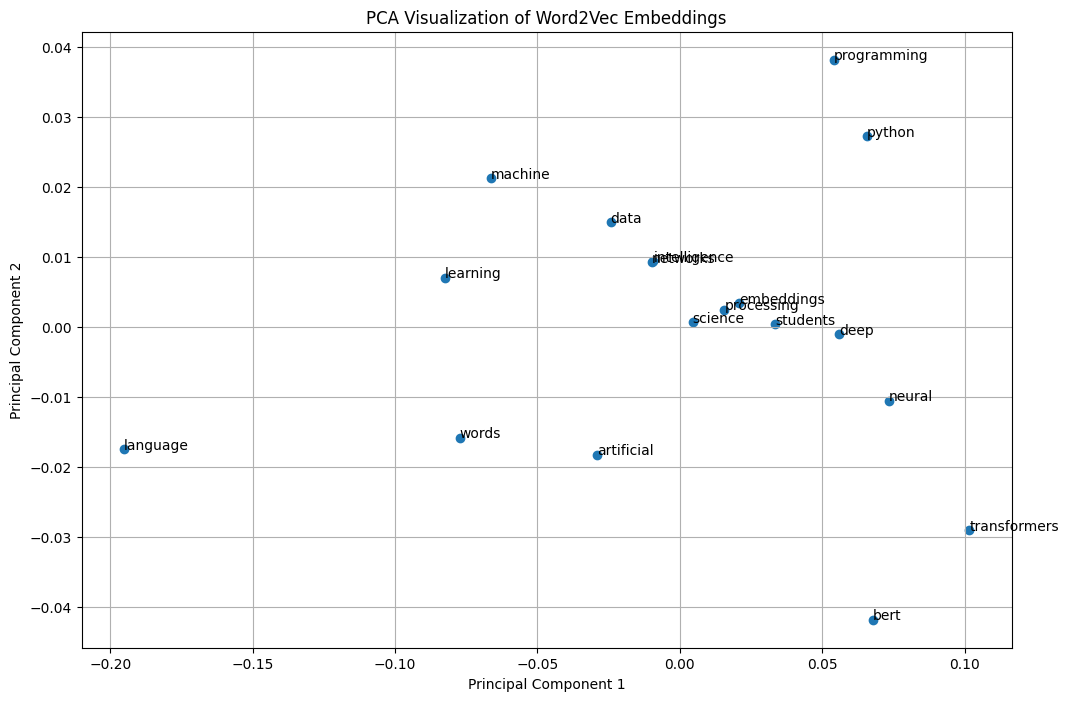

In [ ]:
plt.figure(figsize=(12, 8))

plt.scatter(
    reduced_vectors[:, 0],
    reduced_vectors[:, 1]
)

for i, word in enumerate(available_words):
    plt.annotate(
        word,
        (
            reduced_vectors[i, 0],
            reduced_vectors[i, 1]
        )
    )

plt.title("PCA Visualization of Word2Vec Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

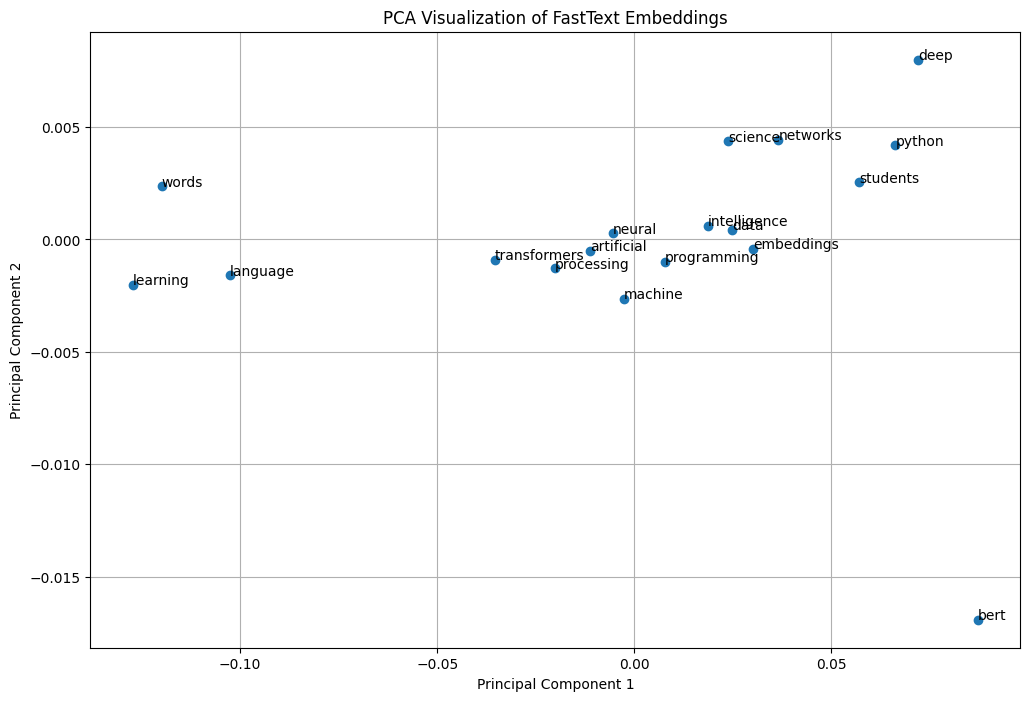

In [ ]:
available_fasttext_words = [
    word for word in visualization_words
    if word in fasttext_model.wv
]

fasttext_vectors = np.array([
    fasttext_model.wv[word]
    for word in available_fasttext_words
])

fasttext_pca = PCA(n_components=2)

fasttext_reduced = fasttext_pca.fit_transform(
    fasttext_vectors
)

plt.figure(figsize=(12, 8))

plt.scatter(
    fasttext_reduced[:, 0],
    fasttext_reduced[:, 1]
)

for i, word in enumerate(available_fasttext_words):
    plt.annotate(
        word,
        (
            fasttext_reduced[i, 0],
            fasttext_reduced[i, 1]
        )
    )

plt.title("PCA Visualization of FastText Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

# 9. Semantic Similarity Using Cosine Similarity

Cosine similarity measures the angle between two vectors.

The value generally ranges from -1 to +1.

A value closer to 1 indicates that the vectors point in similar directions.

Cosine similarity is commonly used to compare word embeddings.

In [ ]:
def cosine_word_similarity(model, word1, word2):
    vector1 = model.wv[word1]
    vector2 = model.wv[word2]

    return cosine_similarity(
        [vector1],
        [vector2]
    )[0][0]


pairs = [
    ("machine", "learning"),
    ("deep", "learning"),
    ("python", "programming"),
    ("data", "science"),
    ("artificial", "intelligence")
]

for word1, word2 in pairs:

    if word1 in word2vec_model.wv and word2 in word2vec_model.wv:

        score = cosine_word_similarity(
            word2vec_model,
            word1,
            word2
        )

        print(
            f"{word1:<15} {word2:<15} "
            f"Similarity = {score:.4f}"
        )

machine         learning        Similarity = 0.9643
deep            learning        Similarity = 0.9442
python          programming     Similarity = 0.9059
data            science         Similarity = 0.9305
artificial      intelligence    Similarity = 0.9414


In [ ]:
comparison_pairs = [
    ("machine", "learning"),
    ("deep", "learning"),
    ("python", "programming"),
    ("data", "science"),
    ("artificial", "intelligence")
]

comparison_results = []

for word1, word2 in comparison_pairs:

    w2v_score = cosine_word_similarity(
        word2vec_model,
        word1,
        word2
    )

    ft_score = cosine_word_similarity(
        fasttext_model,
        word1,
        word2
    )

    comparison_results.append([
        word1,
        word2,
        w2v_score,
        ft_score
    ])

comparison_df = pd.DataFrame(
    comparison_results,
    columns=[
        "Word 1",
        "Word 2",
        "Word2Vec Similarity",
        "FastText Similarity"
    ]
)

comparison_df

,Word 1,Word 2,Word2Vec Similarity,FastText Similarity
0,machine,learning,0.964262,0.997226
1,deep,learning,0.944171,0.983400
2,python,programming,0.905852,0.991314
3,data,science,0.930488,0.990761
4,artificial,intelligence,0.941365,0.996934


# 10. Comparative Analysis

| Technique | Type | Dense/Sparse | Contextual | OOV Handling | Semantic Understanding | Computational Cost |
|---|---|---|---|---|---|---|
| One-Hot | Traditional | Sparse | No | Poor | Very Low | Low |
| BoW | Traditional | Sparse | No | Poor | Low | Low |
| TF-IDF | Traditional | Sparse | No | Poor | Low–Medium | Low |
| Word2Vec | Predictive | Dense | No | Poor | Good | Medium |
| GloVe | Pretrained | Dense | No | Poor | Good | Medium |
| FastText | Subword | Dense | No | Good | Good | Medium |
| Keras Embedding | Neural | Dense | No | Depends on vocabulary | Good | Medium |
| BERT | Transformer | Dense | Yes | Good | Very High | High |
| SBERT | Sentence Transformer | Dense | Yes | Good | Very High | High |

### Analysis

Traditional techniques such as One-Hot Encoding, Bag of Words and TF-IDF are
simple and computationally efficient, but they do not capture deep semantic
relationships between words.

Word2Vec learns dense representations based on the surrounding context of words.
However, standard Word2Vec produces static embeddings and has limited handling
of unseen words.

FastText improves upon Word2Vec by using character-level subword information.
This makes it more effective for rare words and out-of-vocabulary words.

Keras Embedding provides a trainable neural representation that can be learned
as part of a larger neural network.

BERT uses Transformer architecture and generates contextual representations.
The representation of a word changes according to its surrounding context.

Therefore, BERT provides stronger contextual understanding but requires greater
computational resources compared with traditional techniques.

# 11. Experimental Results

### TF-IDF

TF-IDF successfully converts documents into numerical vectors and gives higher
importance to words that are relatively informative within a document.

### Word2Vec

Word2Vec generates dense word vectors and allows semantically related words
to be identified using cosine similarity.

### FastText

FastText generates word representations using character-level subword
information. This allows it to handle rare and unseen words more effectively.

### Keras Embedding

The Keras Embedding layer converts integer word IDs into dense trainable vectors.

### BERT

BERT produces contextual representations. The meaning of a word can change
depending on the sentence in which it occurs.

### Visualization

PCA reduces the high-dimensional embeddings to two dimensions. The resulting
plot helps identify groups of semantically related words.

### Overall Observation

The experiments show the progression from simple frequency-based representations
to predictive word embeddings and finally to contextual Transformer-based
representations.

# 12. Conclusion

This experiment explored different approaches to representing text and words,
starting from traditional methods and progressing toward modern Transformer-based
representations.

One-Hot Encoding and Bag of Words provide simple numerical representations but
do not capture semantic relationships. TF-IDF improves upon frequency-based
representation by assigning importance to informative words, but it still
does not understand context.

Word2Vec learns dense semantic representations by predicting words based on
their surrounding context. FastText improves word representation by incorporating
character-level subword information, allowing better handling of rare and
out-of-vocabulary words.

The TensorFlow/Keras Embedding layer demonstrates how word representations can
be learned as part of a neural network.

BERT represents a major improvement because it generates contextual embeddings.
The same word can receive different representations depending on its surrounding
context.

PCA visualization provides an intuitive way to inspect high-dimensional embeddings
and identify semantic clusters.

Overall, the experiment demonstrates the evolution of text representation from
sparse frequency-based techniques to dense static embeddings and finally to
context-aware Transformer representations.